# CMPE 255 Assignment 1 — Part 2
## Experiment 1: NYC Taxi Trip Duration Prediction

### AI-Assisted Replication of Instructor Data Science Experiment

This notebook replicates and adapts the NYC Taxi Trip Prediction experiment from the instructor's `data_science_examples` repository.

The original experiment requested an end-to-end data science workflow using the Kaggle NYC Taxi dataset, including data preparation, training, deployment concepts, and the CRISP-DM framework.

For this assignment, I adapted the experiment into a reproducible Jupyter/Google Colab workflow focused on the core data science process.

### Objectives

- Follow the CRISP-DM methodology
- Explore and clean NYC taxi trip data
- Perform feature engineering
- Train regression models
- Evaluate model performance
- Interpret important predictors
- Demonstrate trip duration prediction

### Original Instructor Prompt

> "Now on to another project - You will do end2end a data science project of including data, training, deployment, crisp-dm framework, and an awesome front end. you can use Kaggle NYC taxi challenge. make sure that frontend includes interactive map and trip estimation."

### Adaptation

Instead of building a complete production frontend, this notebook focuses on a transparent and reproducible machine learning experiment that demonstrates the core data science components of the original project.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. CRISP-DM: Business Understanding

### Business Problem

Taxi companies and transportation platforms need accurate estimates of trip duration for route planning, customer expectations, driver management, and operational efficiency.

The goal of this experiment is to build a regression model that predicts the duration of a New York City taxi trip using information available around pickup time, including:

- Pickup location
- Dropoff location
- Pickup date and time
- Passenger count
- Vendor information

### Machine Learning Problem

This is a **supervised regression problem**.

The target variable is:

**`trip_duration`** — the total duration of a taxi trip in seconds.

### Success Criteria

The models will be evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

A useful model should outperform a simple baseline prediction and provide interpretable information about the factors associated with trip duration.

In [ ]:
# Load the NYC Taxi Trip Duration dataset
data_url = "https://raw.githubusercontent.com/guebin/DV2023/main/posts/NYCTaxi.csv"

df = pd.read_csv(data_url)

print("Original dataset shape:", df.shape)
df.head()

Original dataset shape: (14587, 11)


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id3194108,1,2016-06-01 11:48:41,2016-06-01 12:19:07,1,-74.005028,40.746452,-73.972008,40.745781,N,1826
2,id3564028,1,2016-01-02 01:16:42,2016-01-02 01:19:56,1,-73.954132,40.774784,-73.947418,40.779633,N,194
3,id1660823,2,2016-03-01 06:40:18,2016-03-01 07:01:37,5,-73.982140,40.775326,-74.009850,40.721699,N,1279
4,id1575277,2,2016-06-11 16:59:15,2016-06-11 17:33:27,1,-73.999229,40.722881,-73.982880,40.778297,N,2052


## 2. CRISP-DM: Data Understanding

The dataset contains records of New York City taxi trips.

Important variables include:

- `vendor_id` — taxi provider identifier
- `pickup_datetime` — pickup date and time
- `dropoff_datetime` — dropoff date and time
- `passenger_count` — number of passengers
- `pickup_longitude` and `pickup_latitude` — pickup coordinates
- `dropoff_longitude` and `dropoff_latitude` — dropoff coordinates
- `store_and_fwd_flag` — whether the trip record was temporarily stored before transmission
- `trip_duration` — trip duration in seconds

The next step is to inspect the dataset structure, data types, missing values, and descriptive statistics before modeling.

In [ ]:
print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape:
(14587, 11)

Column names:
['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration']

Data types:
id                     object
vendor_id               int64
pickup_datetime        object
dropoff_datetime       object
passenger_count         int64
pickup_longitude      float64
pickup_latitude       float64
dropoff_longitude     float64
dropoff_latitude      float64
store_and_fwd_flag     object
trip_duration           int64
dtype: object

Missing values:
id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64


In [ ]:
# Descriptive statistics for numerical variables
df.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,14587.000000,14587.000000,14587.000000,14587.000000,14587.000000,14587.000000,14587.000000
mean,1.535957,1.670186,-73.973736,40.751096,-73.973587,40.751898,959.609721
std,0.498723,1.303632,0.037631,0.027896,0.035127,0.031965,3253.981823
min,1.000000,0.000000,-74.255165,40.544403,-74.255165,40.546734,2.000000
25%,1.000000,1.000000,-73.991913,40.737501,-73.991146,40.736130,398.500000
50%,2.000000,1.000000,-73.981781,40.753876,-73.979507,40.754734,666.000000
75%,2.000000,2.000000,-73.967197,40.768618,-73.963291,40.769754,1078.500000
max,2.000000,6.000000,-73.756332,40.899853,-73.533745,41.031044,86346.000000


In [ ]:
print("Trip Duration Statistics")
print("------------------------")

print("Mean:", df["trip_duration"].mean())
print("Median:", df["trip_duration"].median())
print("Minimum:", df["trip_duration"].min())
print("Maximum:", df["trip_duration"].max())

Trip Duration Statistics
------------------------
Mean: 959.6097209844382
Median: 666.0
Minimum: 2
Maximum: 86346


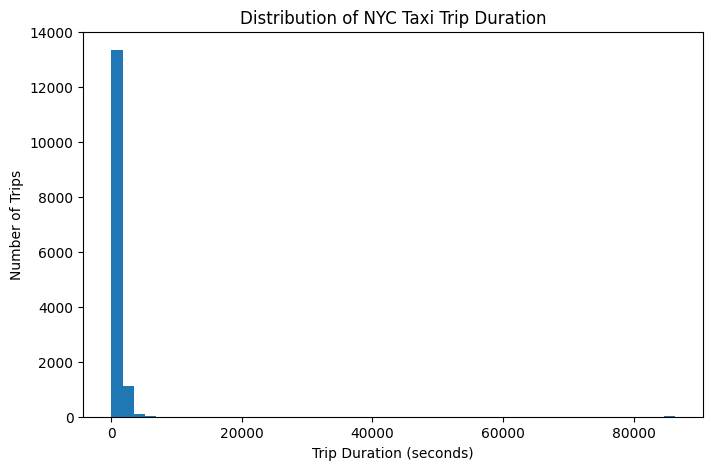

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df["trip_duration"], bins=50)

plt.title("Distribution of NYC Taxi Trip Duration")
plt.xlabel("Trip Duration (seconds)")
plt.ylabel("Number of Trips")

plt.show()

### Data Understanding Findings

The dataset used in this experiment contains 14,587 taxi trips and 11 variables. No missing values were found in the dataset.

The target variable, `trip_duration`, is strongly right-skewed. The median trip duration is 666 seconds (about 11.1 minutes), while the mean is approximately 960 seconds (about 16 minutes).

The maximum recorded trip duration is 86,346 seconds, which is almost 24 hours. The histogram also shows a small number of extremely long trips that distort the distribution.

Before training the regression models, these extreme observations will be filtered to create a more representative modeling dataset.

## 3. CRISP-DM: Data Preparation

The data preparation stage converts the raw taxi records into features that can be used by machine learning models.

The main steps are:

1. Convert pickup timestamps to datetime format.
2. Remove unrealistic or extreme trip durations.
3. Extract temporal features from the pickup time.
4. Calculate the geographical distance between pickup and dropoff locations.
5. Select features that would reasonably be available when estimating a trip duration.

The target variable `trip_duration` will not be used to construct any predictor features in order to avoid data leakage.

In [ ]:
# Remove unrealistic or extreme trip durations

print("Rows before cleaning:", len(df))

df_clean = df[
    (df["trip_duration"] >= 60) &
    (df["trip_duration"] <= 7200)
].copy()

print("Rows after cleaning:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Rows before cleaning: 14587
Rows after cleaning: 14480
Rows removed: 107


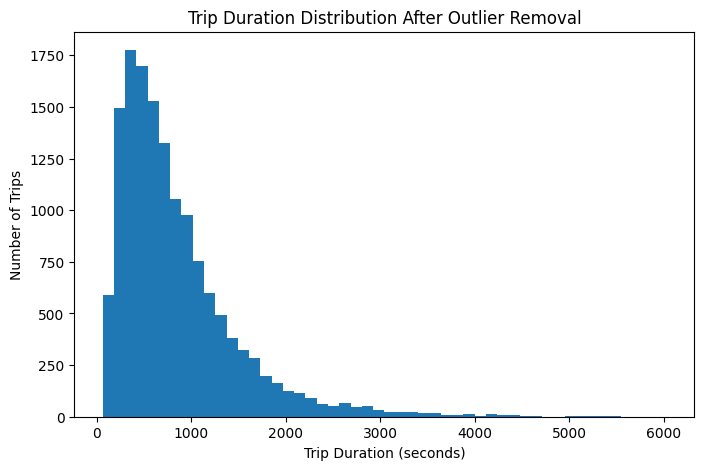

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df_clean["trip_duration"], bins=50)

plt.title("Trip Duration Distribution After Outlier Removal")
plt.xlabel("Trip Duration (seconds)")
plt.ylabel("Number of Trips")

plt.show()

In [ ]:
# Convert pickup time to datetime
df_clean["pickup_datetime"] = pd.to_datetime(
    df_clean["pickup_datetime"]
)

# Create time-based features
df_clean["pickup_hour"] = df_clean["pickup_datetime"].dt.hour
df_clean["pickup_day"] = df_clean["pickup_datetime"].dt.day
df_clean["pickup_month"] = df_clean["pickup_datetime"].dt.month
df_clean["pickup_dayofweek"] = df_clean["pickup_datetime"].dt.dayofweek

df_clean[
    [
        "pickup_datetime",
        "pickup_hour",
        "pickup_day",
        "pickup_month",
        "pickup_dayofweek"
    ]
].head()

,pickup_datetime,pickup_hour,pickup_day,pickup_month,pickup_dayofweek
0,2016-05-15 13:53:24,13,15,5,6
1,2016-06-16 13:09:32,13,16,6,3
2,2016-02-02 12:03:42,12,2,2,1
3,2016-06-21 00:44:49,0,21,6,1
4,2016-06-08 12:27:52,12,8,6,2


In [ ]:
# Calculate geographical distance between pickup and dropoff
# using the Haversine formula

def calculate_distance(lat1, lon1, lat2, lon2):
    earth_radius = 6371  # kilometers

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    lat_difference = lat2 - lat1
    lon_difference = lon2 - lon1

    a = (
        np.sin(lat_difference / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(lon_difference / 2) ** 2
    )

    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    distance = earth_radius * c

    return distance


df_clean["distance_km"] = calculate_distance(
    df_clean["pickup_latitude"],
    df_clean["pickup_longitude"],
    df_clean["dropoff_latitude"],
    df_clean["dropoff_longitude"]
)

df_clean[
    [
        "pickup_latitude",
        "pickup_longitude",
        "dropoff_latitude",
        "dropoff_longitude",
        "distance_km"
    ]
].head()

,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude,distance_km
0,40.752232,-73.974907,40.743778,-73.972809,0.956444
1,40.779198,-73.962196,40.768238,-73.982407,2.093184
2,40.789097,-73.952667,40.795033,-73.971672,1.730697
3,40.743687,-73.984161,40.749569,-73.992493,0.959375
4,40.751575,-73.986237,40.766464,-73.953918,3.185950


In [ ]:
print("Distance Statistics")
print("-------------------")

print("Mean distance:", df_clean["distance_km"].mean())
print("Median distance:", df_clean["distance_km"].median())
print("Minimum distance:", df_clean["distance_km"].min())
print("Maximum distance:", df_clean["distance_km"].max())

Distance Statistics
-------------------
Mean distance: 3.434685737194159
Median distance: 2.1213669934060224
Minimum distance: 0.0
Maximum distance: 42.942671669184875


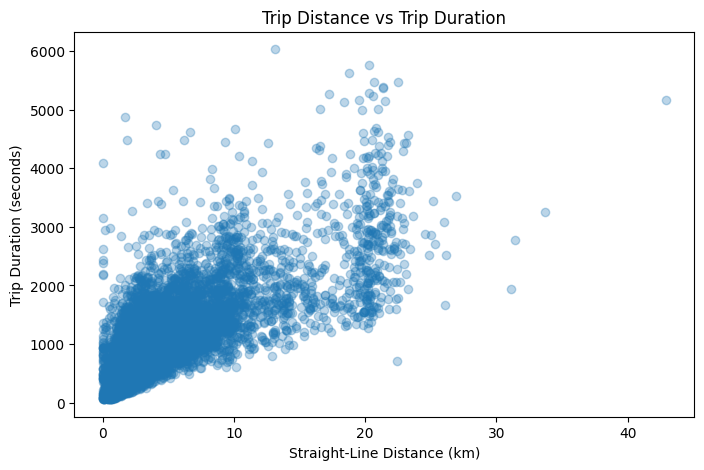

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_clean["distance_km"],
    df_clean["trip_duration"],
    alpha=0.3
)

plt.title("Trip Distance vs Trip Duration")
plt.xlabel("Straight-Line Distance (km)")
plt.ylabel("Trip Duration (seconds)")

plt.show()

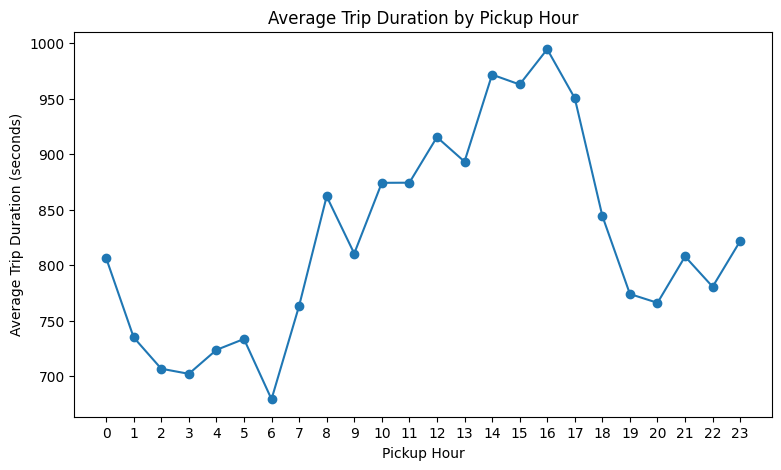

In [ ]:
hourly_duration = (
    df_clean
    .groupby("pickup_hour")["trip_duration"]
    .mean()
)

plt.figure(figsize=(9, 5))

plt.plot(
    hourly_duration.index,
    hourly_duration.values,
    marker="o"
)

plt.title("Average Trip Duration by Pickup Hour")
plt.xlabel("Pickup Hour")
plt.ylabel("Average Trip Duration (seconds)")
plt.xticks(range(0, 24))

plt.show()

### Feature Engineering and EDA Findings

After filtering trips shorter than 60 seconds or longer than two hours, 14,480 of the original 14,587 observations remained. Only 107 records were removed, so most of the original dataset was preserved.

The engineered straight-line trip distance has a median of approximately 2.12 km and a mean of approximately 3.43 km.

The scatter plot shows a clear positive relationship between trip distance and trip duration. Longer trips generally require more time, although substantial variation remains. This variation suggests that distance alone cannot fully explain trip duration.

Pickup time also appears to contain useful predictive information. Average trip duration varies throughout the day and becomes relatively high during the afternoon, with the highest average duration occurring around 4 PM in this sample. Traffic conditions and travel demand may contribute to this pattern, although the dataset alone does not establish causation.

These observations suggest that combining geographical and temporal features may improve trip duration prediction.

## 4. CRISP-DM: Modeling

Two regression models will be compared:

### Model 1: Linear Regression

Linear Regression provides a simple and interpretable baseline for predicting trip duration.

### Model 2: Random Forest Regression

Random Forest can capture nonlinear relationships and interactions between variables that a linear model may not represent effectively.

The models will use the same training and testing data so that their performance can be compared fairly.

### Selected Features

The following predictors are used:

- Passenger count
- Pickup longitude and latitude
- Dropoff longitude and latitude
- Pickup hour
- Pickup day
- Pickup month
- Pickup day of week
- Engineered straight-line trip distance

The target variable is `trip_duration`.

In [ ]:
# Select features for machine learning

features = [
    "passenger_count",
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",
    "pickup_hour",
    "pickup_day",
    "pickup_month",
    "pickup_dayofweek",
    "distance_km"
]

X = df_clean[features]
y = df_clean["trip_duration"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

X.head()

Feature matrix shape: (14480, 10)
Target shape: (14480,)


,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,pickup_hour,pickup_day,pickup_month,pickup_dayofweek,distance_km
0,1,-73.974907,40.752232,-73.972809,40.743778,13,15,5,6,0.956444
1,3,-73.962196,40.779198,-73.982407,40.768238,13,16,6,3,2.093184
2,1,-73.952667,40.789097,-73.971672,40.795033,12,2,2,1,1.730697
3,1,-73.984161,40.743687,-73.992493,40.749569,0,21,6,1,0.959375
4,1,-73.986237,40.751575,-73.953918,40.766464,12,8,6,2,3.185950


In [ ]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 11584
Testing samples: 2896


In [ ]:
# Simple baseline model:
# predict the training-set mean duration for every test trip

baseline_prediction = y_train.mean()

baseline_predictions = np.full(
    len(y_test),
    baseline_prediction
)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

print("Baseline Results")
print("----------------")
print("Prediction used:", round(baseline_prediction, 2), "seconds")
print("MAE:", round(baseline_mae, 2))
print("RMSE:", round(baseline_rmse, 2))

Baseline Results
----------------
Prediction used: 840.78 seconds
MAE: 458.86
RMSE: 650.25


In [ ]:
# Model 1: Linear Regression

linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression Results")
print("-------------------------")
print("MAE:", round(linear_mae, 2))
print("RMSE:", round(linear_rmse, 2))
print("R²:", round(linear_r2, 4))

Linear Regression Results
-------------------------
MAE: 280.58
RMSE: 406.37
R²: 0.6094


In [ ]:
# Model 2: Random Forest Regression

random_forest = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

rf_predictions = random_forest.predict(X_test)

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest Results")
print("---------------------")
print("MAE:", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R²:", round(rf_r2, 4))

Random Forest Results
---------------------
MAE: 218.93
RMSE: 334.48
R²: 0.7353


In [ ]:
# Compare model performance

model_results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        baseline_mae,
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        baseline_rmse,
        linear_rmse,
        rf_rmse
    ],
    "R2": [
        np.nan,
        linear_r2,
        rf_r2
    ]
})

model_results.round(3)

,Model,MAE,RMSE,R2
0,Baseline,458.860,650.249,NaN
1,Linear Regression,280.581,406.365,0.609
2,Random Forest,218.927,334.476,0.735


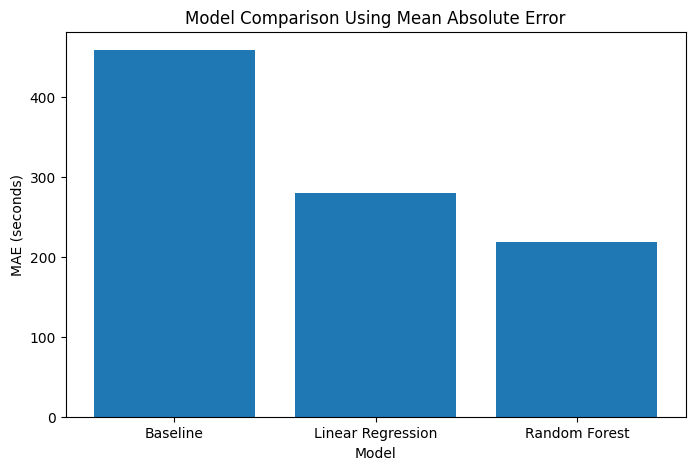

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    model_results["Model"],
    model_results["MAE"]
)

plt.title("Model Comparison Using Mean Absolute Error")
plt.ylabel("MAE (seconds)")
plt.xlabel("Model")

plt.show()

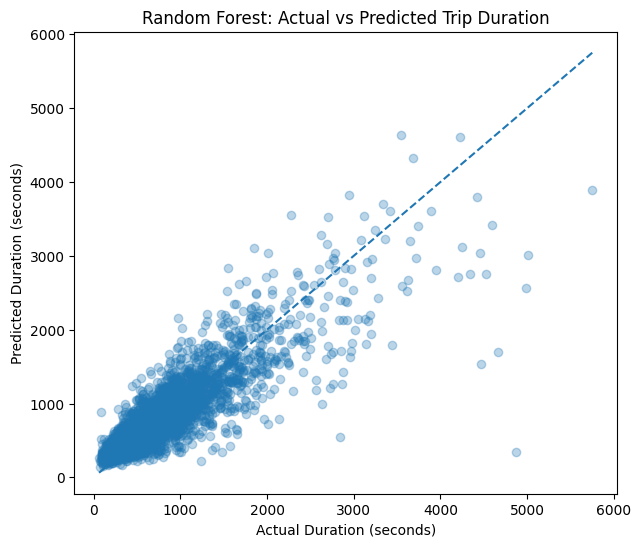

In [ ]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.3
)

minimum = min(y_test.min(), rf_predictions.min())
maximum = max(y_test.max(), rf_predictions.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.title("Random Forest: Actual vs Predicted Trip Duration")
plt.xlabel("Actual Duration (seconds)")
plt.ylabel("Predicted Duration (seconds)")

plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
9,distance_km,0.684179
5,pickup_hour,0.076994
4,dropoff_latitude,0.047633
3,dropoff_longitude,0.041198
1,pickup_longitude,0.040854
2,pickup_latitude,0.031346
6,pickup_day,0.027284
8,pickup_dayofweek,0.025795
7,pickup_month,0.017709
0,passenger_count,0.007008


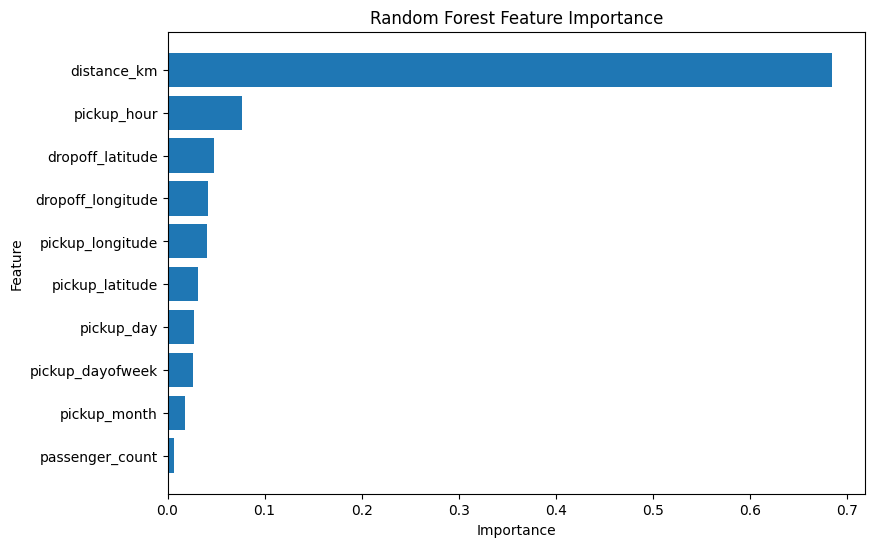

In [ ]:
plt.figure(figsize=(9, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

## 5. CRISP-DM: Evaluation

The three prediction approaches produced the following results:

- **Baseline:** MAE = 458.86 seconds, RMSE = 650.25 seconds
- **Linear Regression:** MAE = 280.58 seconds, RMSE = 406.37 seconds, R² = 0.6094
- **Random Forest:** MAE = 218.93 seconds, RMSE = 334.48 seconds, R² = 0.7353

Random Forest achieved the best overall performance.

Compared with the simple baseline, Random Forest reduced the mean absolute error from approximately 459 seconds to 219 seconds, a reduction of about 52%.

The Random Forest R² score of 0.7353 indicates that the model explains approximately 73.5% of the variation in trip duration in the test data.

The nonlinear Random Forest model also substantially outperformed Linear Regression, suggesting that the relationship between trip characteristics and trip duration is not entirely linear.

### Model Interpretation

The Random Forest feature importance analysis shows that `distance_km` is the most influential predictor, with an importance of approximately 0.684.

The second most important feature is `pickup_hour`, followed by the pickup and dropoff geographical coordinates.

This result is consistent with the exploratory analysis: longer trips generally require more travel time, while the time of day also appears to contain useful information for predicting trip duration.

Passenger count has relatively little importance in this model.

Feature importance describes how useful variables were for prediction within the Random Forest model. It should not be interpreted as evidence that these variables directly cause changes in trip duration.

## 6. Trip Duration Prediction Demo

To demonstrate how the trained model could support a trip estimation application, the following example uses one previously unseen trip from the test set.

The model receives the trip characteristics and produces an estimated trip duration.

In [ ]:
# Demonstrate a prediction using one trip from the test set

example_index = 0

example_trip = X_test.iloc[[example_index]]
actual_duration = y_test.iloc[example_index]

predicted_duration = random_forest.predict(
    example_trip
)[0]

print("Trip Duration Prediction Demo")
print("-----------------------------")

print(
    "Actual duration:",
    round(actual_duration, 2),
    "seconds"
)

print(
    "Predicted duration:",
    round(predicted_duration, 2),
    "seconds"
)

print(
    "Actual duration:",
    round(actual_duration / 60, 2),
    "minutes"
)

print(
    "Predicted duration:",
    round(predicted_duration / 60, 2),
    "minutes"
)

print(
    "Absolute error:",
    round(
        abs(actual_duration - predicted_duration) / 60,
        2
    ),
    "minutes"
)

Trip Duration Prediction Demo
-----------------------------
Actual duration: 986 seconds
Predicted duration: 968.71 seconds
Actual duration: 16.43 minutes
Predicted duration: 16.15 minutes
Absolute error: 0.29 minutes


## 7. CRISP-DM: Deployment Discussion

The original instructor experiment included the idea of deploying the model through an interactive application with trip estimation.

In a production system, the trained Random Forest model could be exposed through a web API. A user could provide pickup location, destination, passenger information, and pickup time through a web or mobile interface.

The application would:

1. Receive trip information from the user.
2. Calculate the engineered distance and time features.
3. Send the features to the trained model.
4. Generate an estimated trip duration.
5. Display the estimated travel time to the user.

For this assignment replication, deployment is demonstrated conceptually through the prediction example rather than implementing a complete production frontend.

## 8. Experiment Conclusion

This experiment replicated and adapted the instructor's NYC Taxi Trip Prediction project using the CRISP-DM framework.

The workflow included:

- Business understanding
- Data understanding
- Outlier handling
- Temporal feature engineering
- Geographical distance engineering
- Baseline modeling
- Linear Regression
- Random Forest Regression
- Model evaluation
- Feature importance analysis
- A trip duration prediction demonstration
- Deployment discussion

Random Forest achieved the strongest performance with:

- **MAE:** 218.93 seconds
- **RMSE:** 334.48 seconds
- **R²:** 0.7353

The model reduced MAE by approximately 52% compared with the simple baseline.

Straight-line trip distance was the most important predictive feature, followed by pickup hour and geographical location features.

Overall, the experiment demonstrates how AI-assisted coding can be used to rapidly reproduce and adapt an end-to-end data science workflow while still applying standard machine learning methodology and interpreting the resulting model.